# Config
Configurazioni generali dell'addestramento:

In [20]:
import torch

BATCH_SIZE = 8

EPOCHS = 25
DEVICE = torch.device("cuda")

# Rete
La rete sviluppata è una rete in grado di segmentare un'immagine e restituire 1 = foreground e 0 = background, essa si basa su una rete preaddestrata DeepLab con backbone MobileNet addestrata su il dataset COCO:

In [21]:
import torch.nn as nn
from torchvision.models.segmentation import deeplabv3_mobilenet_v3_large, DeepLabV3_MobileNet_V3_Large_Weights

class ForegroundExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT

        self.model = deeplabv3_mobilenet_v3_large(weights=self.weights)
        in_channels = self.model.classifier[4].in_channels
        self.model.classifier[4] = nn.Conv2d(in_channels, 1, kernel_size=(1, 1), stride=(1, 1))

    def forward(self, x):
        return self.model(x)

# Trainer
Il fine tuning della rete viene eseguito per 25 epoche usando una BCELoss e un ottimizzatore SGD con lr impostato a 1e-4.

Per ogni epoca di addestramento vengono calcolati gli indici IOU e Dice.

In [22]:
import torch
import torch.nn as nn

from tqdm import tqdm

class ForegroundExtractorTrainer:
    def __init__(self, device: str):
        self.device = device
        self.model = ForegroundExtractor().to(self.device)
        self.optimizer = torch.optim.SGD(self.model.parameters(), lr=1e-4, momentum=0.9, weight_decay=1e-4)
        self.criterion = nn.BCEWithLogitsLoss()

        self.history = {
            "train_loss": [],
            "valid_loss": [],
            "iou": [],
            "dice": [],
        }

    def __train_step__(
        self,
        images: torch.Tensor,
        targets: torch.Tensor) -> torch.Tensor:
        """
        Step di addestramento del modello.

        Args:
            images (torch.Tensor): tensore contente il batch di immagini del dataset
            targets (torch.Tensor): tensore contente il batch di maschere del dataset

        Returns:
            torch.Tensor: perdita dello step di addestramento
        """
        self.model.train()
        self.optimizer.zero_grad()

        preds = self.model.forward(images)['out']

        loss = self.criterion(preds, targets)
        loss.backward()

        self.optimizer.step()
        return loss

    def __valid_step__(
        self,
        images: torch.Tensor,
        targets: torch.Tensor):
        """
        Step di validazione del modello.

        Args:
            images (torch.Tensor): tensore contente il batch di immagini del dataset
            targets (torch.Tensor): tensore contente il batch di maschere del dataset

        Returns:
            torch.Tensor: perdita dello step di validazione
            float: valore di iou (totale)
            float: valore di dice (totale)
        """
        self.model.eval()
        with torch.no_grad():
            preds = self.model.forward(images)['out']
            loss = self.criterion(preds, targets)

            preds = (torch.sigmoid(preds) > 0.5).int()
            targets = targets.int()

            intersection = ((preds == 1) & (targets == 1)).sum().item()
            union = ((preds == 1) | (targets == 1)).sum().item()
            iou = intersection / (union + 1e-7)

            dice = (2 * intersection) / (preds.sum().item() + targets.sum().item() + 1e-7)
        return loss, iou, dice

    def __print_epoch__(
        self,
        epoch: int,
        epochs: int,
        train_loss: float,
        valid_loss: float):
        """
        Stampa il resoconto dell'epoca di addestramento

        Args:
            epoch (_type_): epoca attuale.
            epochs (int, optional): epoche di addestramento.
            train_loss (_type_): perdita di addestramento.
            valid_loss (_type_): perdita di validazione.
        """
        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Valid Loss: {valid_loss:.4f}")

    def train_loop(
        self,
        train_dataloader: torch.utils.data.DataLoader,
        valid_dataloader: torch.utils.data.DataLoader,
        save_path: str,
        epochs: int = 25,
        patience: int = 5):
        """
        Loop di addestramento del modello.

        Args:
            train_dataloader (torch.utils.data.DataLoader): dataloader del dataset di addestramento
            valid_dataloader (torch.utils.data.DataLoader): dataloader del dataset di validazione
            save_path (str): percorso dove salvare il modello
            epochs (int, optional): epoche di addestramento. Default a 25.
            patience (int, optional): epoche di pazienza per l'early stopping. Default a 5.

        Returns:
            dict[str, list]: dizionario contenente la storia dell'addestramento
        """
        best_valid_loss = float('inf')
        epochs_no_improve = 0
        for epoch in range(epochs):
            torch.cuda.empty_cache()

            running_train_loss = 0.0
            pb_train_dataloader = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
            for batch in pb_train_dataloader:
                loss = self.__train_step__(
                    batch["images"].to(self.device),
                    batch["targets"].to(self.device)
                )

                running_train_loss += loss.item()
                pb_train_dataloader.set_postfix(
                    train_loss = running_train_loss  / (pb_train_dataloader.n + 1)
                )

            avg_train_loss = running_train_loss / len(train_dataloader)
            self.history["train_loss"].append(avg_train_loss)

            running_valid_loss = 0.0
            running_iou = 0.0
            running_dice = 0.0
            pb_valid_dataloader = tqdm(valid_dataloader, desc=f"Epoch {epoch+1}/{epoch}", leave=False)
            for batch in pb_valid_dataloader:
                loss, iou, dice = self.__valid_step__(
                    batch["images"].to(self.device),
                    batch["targets"].to(self.device)
                )

                running_valid_loss += loss.item()
                running_iou += iou
                running_dice += dice
                pb_valid_dataloader.set_postfix(
                    valid_loss = running_valid_loss  / (pb_train_dataloader.n + 1)
                )

            avg_valid_loss = running_valid_loss / len(valid_dataloader)
            self.history["valid_loss"].append(avg_valid_loss)

            avg_iou = running_iou / len(valid_dataloader)
            self.history["iou"].append(avg_iou)

            avg_dice = running_dice / len(valid_dataloader)
            self.history["dice"].append(avg_dice)

            self.__print_epoch__(epoch, epochs, avg_train_loss, avg_valid_loss)
            if avg_valid_loss < best_valid_loss:
                best_valid_loss = avg_valid_loss
                epochs_no_improve = 0
                torch.save(self.model.state_dict(), save_path)
                print("  --> Model saved!")
            else:
                epochs_no_improve += 1
                print(f"No improvement for {epochs_no_improve} epochs.")

            if epochs_no_improve >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs.")
                break

        return self.history

# Dataset
Il dataset utilizzato è caricato tramite la libreria deeplake (libreria zoo di dataset) e viene usato il dataset Extended Complex Scene Saliency Dataset, un dataset con sole maschere di foreground di alta qualità:

In [23]:
import torch
import deeplake

import numpy as np

ECSSD_DS_PATH = "hub://activeloop/ecssd"

class DeeplakeSegmentationDataset(torch.utils.data.Dataset):
    def __init__(self, load_path: str, transform=None):
        super().__init__()
        ds = deeplake.load(load_path)
        self.images = ds.images
        self.masks = ds.masks

        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx) -> tuple[torch.Tensor, torch.Tensor]:
        image = self.images[idx].numpy()
        if image.shape[2] == 1: image = np.concatenate([image]*3, axis=-1)
        mask = self.masks[idx].numpy().astype('uint8')

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        mask = mask.permute(2, 0, 1).float() # [1, H, W]
        return image, mask

# Start
Di seguito il codice per avviare l'addestramento del segmentatore:

In [24]:
import albumentations as A

def collate_fn(batch):
    images = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[1] for item in batch])
    return {
        "images": images,
        "targets": targets
    }

# Estratti da DeepLabV3_MobileNet_V3_Large_Weights.DEFAULT.transforms()
transform = A.Compose([
    A.Resize(520, 520),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    A.pytorch.ToTensorV2()
], additional_targets={'mask': 'mask'})
dataset = DeeplakeSegmentationDataset(ECSSD_DS_PATH, transform=transform)

# Suddivisione train/valid 80/20
dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
valid_size = dataset_size - train_size

# Split casuale
train_dataset, valid_dataset = torch.utils.data.random_split(dataset, [train_size, valid_size])

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

trainer = ForegroundExtractorTrainer(DEVICE)
history = trainer.train_loop(
    train_dataloader,
    valid_dataloader,
    save_path="foreground_extractor.pth",
    epochs=EPOCHS,
    patience=5
)

KeyboardInterrupt: 

# Visualizzazione
Completato l'addestramento tramite la storia salvata possiamo visualizzare le statistiche di addestramento del dataset:

In [ ]:
import matplotlib.pyplot as plt

class ForegroundExtractorVisualizer:
    def __init__(self,
                 train_history: dict[str, list]):
        self.history = train_history

    def plot_losses(self):
        """
        Crea il graico con le perdite del modello.
        """
        plt.figure(figsize=(8,5))
        plt.plot(self.history["train_loss"], label="Train Loss")
        plt.plot(self.history["valid_loss"], label="Valid Loss")
        plt.xlabel("Epochs")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_iou(self):
        """
        Crea il graico con l'indice IOU del modello.
        """
        plt.figure(figsize=(8,5))
        plt.plot(self.history["iou"], label="IOU")
        plt.xlabel("Epochs")
        plt.ylabel("IOU")
        plt.title("Intersection over Union (IOU)")
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_dice(self):
        """
        Crea il grafico con l'indice Dice del modello.
        """
        plt.figure(figsize=(8,5))
        plt.plot(self.history["dice"], label="Dice")
        plt.xlabel("Epochs")
        plt.ylabel("Dice")
        plt.title("Dice Coefficient")
        plt.legend()
        plt.grid(True)
        plt.show()

# Start
Di seguito il codice per visualizzare le statistiche del segmentatore:

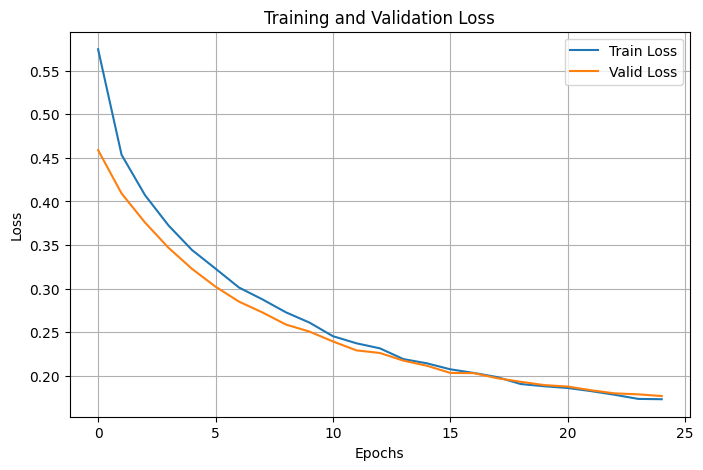

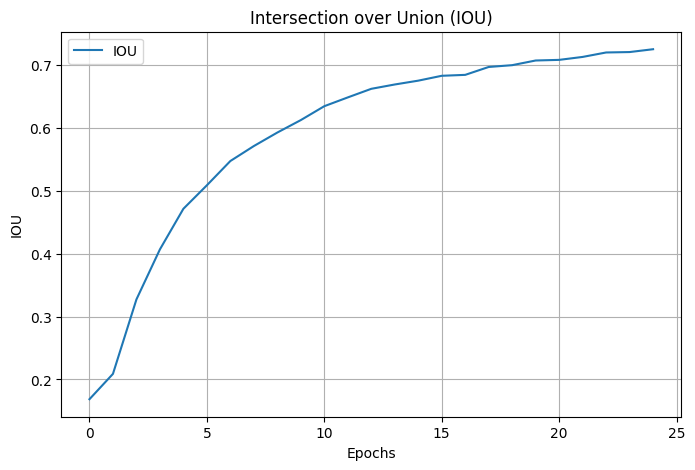

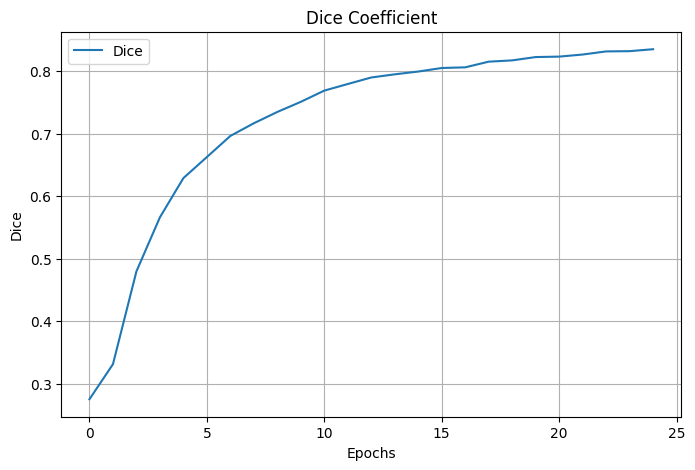

In [ ]:
visualizer = ForegroundExtractorVisualizer(history)
visualizer.plot_losses()
visualizer.plot_iou()
visualizer.plot_dice()

# Test
Come test per capire l'effettivo funzionamento della rete e le sue capacità di generalizzazione proviamolo su alcune immagini di interesse:

In [ ]:
import torch
import numpy as np

class ForegroundExtractorPredictor:
    def __init__(
        self, 
        model_path: str, 
        device: str):
        
        self.device = device
        self.model = ForegroundExtractor().to(self.device)
        self.model.load_state_dict(torch.load(model_path, map_location=self.device))
        
    def predict(
        self, 
        x: torch.Tensor
        ) -> np.ndarray:
        """
        Effettua le predizioni sul modello di estrazione del foreground.

        Args:
            x (torch.Tensor): immagini in input

        Returns:
            np.ndarray: maschere di output 
        """
        self.model.eval()
        with torch.no_grad():
            x = x.to(self.device)
            preds = self.model(x)["out"]
            preds = (torch.sigmoid(preds) > 0.5).int().cpu().numpy()
        return preds

# Start
Di seguito il codice per avviare il test della rete:

In [ ]:
import os
import matplotlib.pyplot as plt
import albumentations as A

predictor = ForegroundExtractorPredictor("C:/Users/Easy4Pro/Desktop/Easy4pro/NeuralZoo/models_zoo/cnn/models/foreground_extractor.pth", "cpu")

dir_path = input("Inserisci il percorso della cartella contenente le immagini di test: ")
for img_path in os.listdir(dir_path):
    if img_path.lower().endswith(('.png', '.jpg', '.jpeg')):
        image = plt.imread(os.path.join(dir_path, img_path))
        if image.shape[2] == 1: image = np.concatenate([image]*3, axis=-1)

        transform = A.Compose([
                A.Resize(520, 520),
                A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                A.pytorch.ToTensorV2()
        ])
        image = transform(image=image)["image"].unsqueeze(0)  # Aggiungi dimensione batch

        mask = predictor.predict(image)[0,0]  # Rimuovi dimensione batch e canale

        image = image.squeeze(0).permute(1, 2, 0).cpu().numpy()
        plt.figure(figsize=(10,5))
        plt.subplot(1,2,1)
        plt.title("Input Image")
        plt.imshow(image)
        plt.axis('off')

        plt.subplot(1,2,2)
        plt.title("Predicted Mask")
        plt.imshow(mask, cmap='gray')
        plt.axis('off')

        plt.show()